In [35]:
import operator
from typing import Annotated, TypedDict

from IPython.display import Image, display
from langgraph.graph import END, START, StateGraph

In [36]:
class State(TypedDict):
  nlist: Annotated[list[str], operator.add]
  

In [37]:
class AppendingNode:
  def __init__(self, node_name: str):
    self.node_name = node_name
  
  def __call__(self, state: State) -> State:
    appended_string = self.node_name.lower()
    log_text = (
      f"Current Node is: {self.node_name}, Appending string \"{appended_string}\","
      f"to previous state: {state['nlist']}"
    )
    print(log_text)
    return State(nlist=[appended_string])

In [38]:
class NodeFactory:
  @staticmethod
  def create_node(node_name: str) -> AppendingNode:
    return AppendingNode(node_name)

In [39]:
builder = StateGraph(State)
node_names = ["A", "B", "C", "BB", "CC", "D"]
factory = NodeFactory()

for name in node_names:
  builder.add_node(name, factory.create_node(name))

builder.add_edge(START, "A")
builder.add_edge("A", "B")
builder.add_edge("A", "C")
builder.add_edge("B", "BB")
builder.add_edge("C", "CC")
builder.add_edge("BB", "D")
builder.add_edge("CC", "D")
builder.add_edge("D", END)

graph = builder.compile()


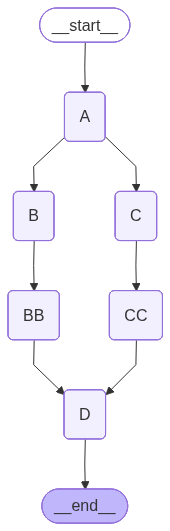

In [40]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [41]:
initial_state = State(
  nlist = ["Initial STRRRRRR"]
)
graph.invoke(initial_state)

Current Node is: A, Appending string "a",to previous state: ['Initial STRRRRRR']
Current Node is: B, Appending string "b",to previous state: ['Initial STRRRRRR', 'a']
Current Node is: C, Appending string "c",to previous state: ['Initial STRRRRRR', 'a']
Current Node is: BB, Appending string "bb",to previous state: ['Initial STRRRRRR', 'a', 'b', 'c']
Current Node is: CC, Appending string "cc",to previous state: ['Initial STRRRRRR', 'a', 'b', 'c']
Current Node is: D, Appending string "d",to previous state: ['Initial STRRRRRR', 'a', 'b', 'c', 'bb', 'cc']


{'nlist': ['Initial STRRRRRR', 'a', 'b', 'c', 'bb', 'cc', 'd']}